In [19]:
import pandas as pd

df = pd.read_csv('Lab 8 - Sheet1.csv')
df.head()

,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes


In [20]:
print(df.shape)


(50, 6)


In [21]:
df["Play Tennis"].value_counts()

Play Tennis
Yes    34
No     16
Name: count, dtype: int64

In [22]:
df = df.drop("No", axis=1)

In [23]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

Outlook
['Sunny' 'Overcast' 'Rain']

Temperature
['Hot' 'Mild' 'Cool']

Humidity
['High' 'Normal']

Wind
['Weak' 'Strong']

Play Tennis
['No' 'Yes']



In [24]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

    print(f"\n{col}")

    for original, encoded in zip(le.classes_, le.transform(le.classes_)):
        print(f"{original} -> {encoded}")


Outlook
Overcast -> 0
Rain -> 1
Sunny -> 2

Temperature
Cool -> 0
Hot -> 1
Mild -> 2

Humidity
High -> 0
Normal -> 1

Wind
Strong -> 0
Weak -> 1

Play Tennis
No -> 0
Yes -> 1


In [25]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


In [26]:
X = df.drop("Play Tennis", axis=1)

y = df["Play Tennis"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\nTraining Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Training Samples : 40
Testing Samples  : 10

Training Class Distribution
Play Tennis
1    27
0    13
Name: count, dtype: int64

Testing Class Distribution
Play Tennis
1    7
0    3
Name: count, dtype: int64


In [28]:
from sklearn.naive_bayes import CategoricalNB

nb = CategoricalNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9

Confusion Matrix
[[2 1]
 [0 7]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



correctly classified 9 out of the 10 testing samples,so accuracy of 90%.

the model did not predict "No" when actual was "Yes". Recall is high for yes



In [30]:
comparison = X_test.copy()

comparison["Actual"] = y_test.values

comparison["Predicted"] = y_pred

comparison[comparison["Actual"] != comparison["Predicted"]]

,Outlook,Temperature,Humidity,Wind,Actual,Predicted
7,2,2,0,1,0,1


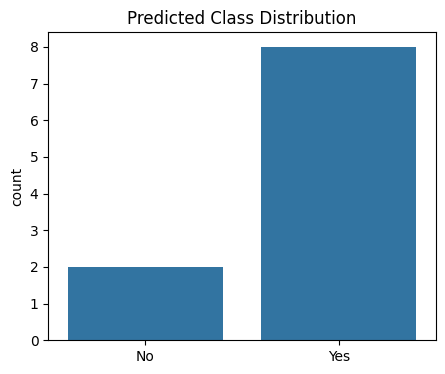

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.countplot(x=y_pred)

plt.xticks([0,1],["No","Yes"])

plt.title("Predicted Class Distribution")

plt.show()

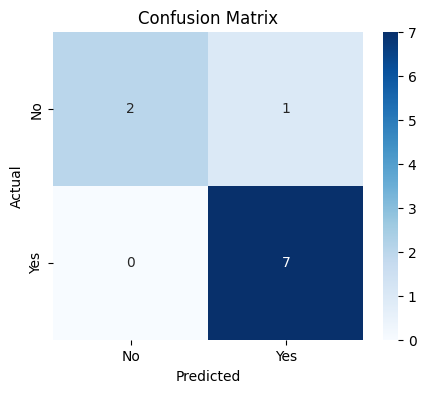

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["No","Yes"],

    yticklabels=["No","Yes"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [35]:
new_data = pd.DataFrame({

    "Outlook":[
        encoders["Outlook"].transform(["Sunny"])[0]
    ],

    "Temperature":[
        encoders["Temperature"].transform(["Cool"])[0]
    ],

    "Humidity":[
        encoders["Humidity"].transform(["High"])[0]
    ],

    "Wind":[
        encoders["Wind"].transform(["Strong"])[0]
    ]

})

In [36]:
prediction = nb.predict(new_data)

print("Predicted Class:")

print(
    encoders["Play Tennis"].inverse_transform(prediction)[0]
)

Predicted Class:
No


In [37]:
prob = nb.predict_proba(new_data)

print("Class Probabilities")

print("No :", prob[0][0])

print("Yes:", prob[0][1])

Class Probabilities
No : 0.7894432811033288
Yes: 0.21055671889667127


In [43]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test,y_pred_dt)

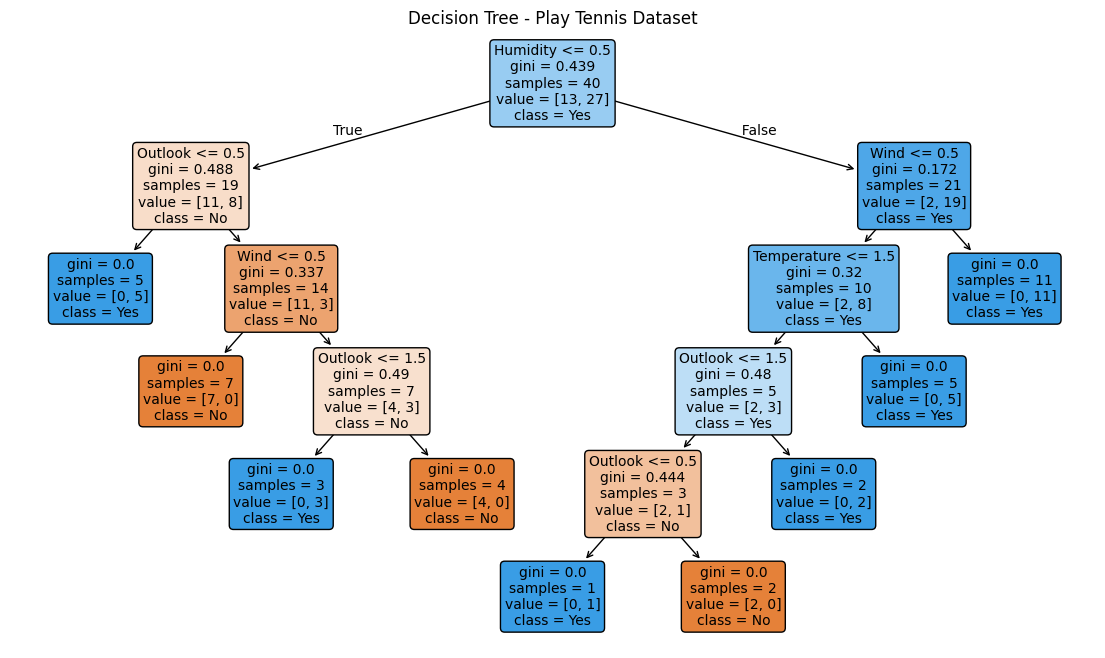

In [51]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14,8))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Play Tennis Dataset")
plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test,y_pred_lr)

In [45]:
comparison = pd.DataFrame({

    "Model":[
        "Categorical Naive Bayes",
        "Decision Tree",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy,
        dt_accuracy,
        lr_accuracy
    ]

})

comparison

,Model,Accuracy
0,Categorical Naive Bayes,0.9
1,Decision Tree,1.0
2,Logistic Regression,0.9


In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({

    "Model":[
        "Categorical Naive Bayes",
        "Decision Tree",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_lr)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_lr)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_lr)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_lr)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Categorical Naive Bayes,0.9,0.875,1.0,0.933333
1,Decision Tree,1.0,1.000,1.0,1.000000
2,Logistic Regression,0.9,0.875,1.0,0.933333


In [47]:
comparison_models = pd.DataFrame({

    "Actual": y_test,

    "Naive Bayes": y_pred,

    "Decision Tree": y_pred_dt,

    "Logistic Regression": y_pred_lr

})

comparison_models

,Actual,Naive Bayes,Decision Tree,Logistic Regression
7,0,1,0,1
49,1,1,1,1
15,0,0,0,0
39,1,1,1,1
9,1,1,1,1
18,1,1,1,1
44,1,1,1,1
3,1,1,1,1
40,0,0,0,0
35,1,1,1,1


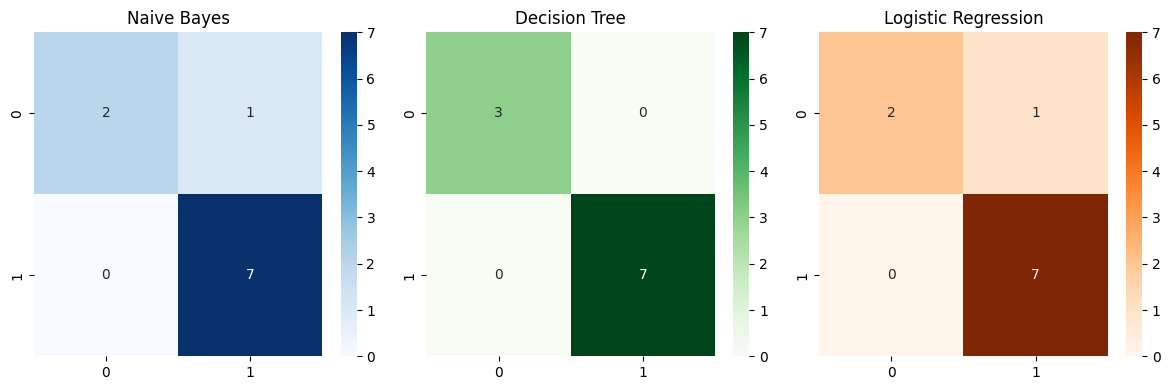

In [49]:
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test,y_pred)
cm_dt = confusion_matrix(y_test,y_pred_dt)
cm_lr = confusion_matrix(y_test,y_pred_lr)

fig,ax=plt.subplots(1,3,figsize=(12,4))

sns.heatmap(cm_nb,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax[0])

ax[0].set_title("Naive Bayes")

sns.heatmap(cm_dt,
            annot=True,
            fmt="d",
            cmap="Greens",
            ax=ax[1])

ax[1].set_title("Decision Tree")

sns.heatmap(cm_lr,
            annot=True,
            fmt="d",
            cmap="Oranges",
            ax=ax[2])

ax[2].set_title("Logistic Regression")

plt.tight_layout()

plt.show()

Decision tree performs better here.

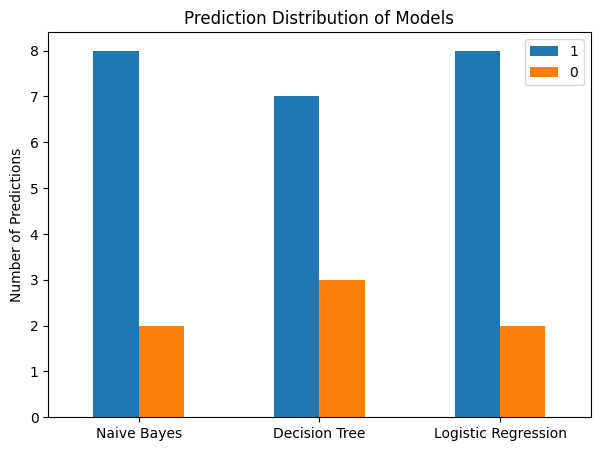

In [50]:
predictions = pd.DataFrame({

    "Naive Bayes":y_pred,

    "Decision Tree":y_pred_dt,

    "Logistic Regression":y_pred_lr

})

predictions.apply(pd.Series.value_counts).T.plot(
    kind="bar",
    figsize=(7,5)
)

plt.xticks(rotation=0)

plt.ylabel("Number of Predictions")

plt.title("Prediction Distribution of Models")

plt.show()